# Tesla FSD Global Adoption Analysis
### A Data Analyst's Deep Dive into the Global Rollout of Full Self-Driving (Supervised)

**Question:** Tesla says ~25% of the world's population now has access to Full Self-Driving (Supervised). How real is that number, what's holding adoption back in the US, and what would it take to scale FSD globally under local laws?

This notebook explores the current state of Tesla's FSD rollout, combining data from regulatory approval tracking, US NHTSA investigation history, and the untapped expansion pipeline. 

#### Key Themes and Insights Highlighted in This Project:
1. **Adoption is shaped more by regulation than by technology:** The physical software is ready, but regulatory gates determine where it can actually be used.
2. **Public narratives don’t always match incident data:** The media narrative focuses intensely on safety failures, yet safety statistics show FSD is multiple times safer than human driving averages.
3. **Major FSD releases create measurable subscription spikes:** Subscriptions react aggressively to price cuts, trials, and new capabilities (e.g. v12, v14).
4. **The biggest barrier isn’t capability — it’s trust:** Regulators and consumers require safety verification, transparent data sharing, and compliance before adoption takes off.

In [1]:
import sqlite3
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# Set matplotlib backend to inline for Jupyter rendering
%matplotlib inline

# Set high-quality styling parameters
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['figure.dpi'] = 150
print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Data and Set Up SQLite DB
We load the curated source files and load them into a SQLite database `data/processed/fsd.db` so the SQL queries are reproducible.

In [2]:
ROOT = Path(__file__).resolve().parents[1] if '__file__' in locals() else Path.cwd().parent
if not (ROOT / "data").exists():
    ROOT = Path.cwd()

RAW = ROOT / "data/raw"
OUT = ROOT / "data/processed"
IMG = ROOT / "docs/img"
OUT.mkdir(parents=True, exist_ok=True)
IMG.mkdir(parents=True, exist_ok=True)

print(f"Project root path: {ROOT}")

# Load datasets
approvals = pd.read_csv(RAW / "fsd_country_approvals.csv", parse_dates=["approval_date"])
events = pd.read_csv(RAW / "us_regulatory_events.csv", parse_dates=["event_date"])
pipeline = pd.read_csv(RAW / "expansion_pipeline.csv")

# Write into sqlite3 DB
con = sqlite3.connect(OUT / "fsd.db")
approvals.to_sql("fsd_country_approvals", con, if_exists="replace", index=False)
events.to_sql("us_regulatory_events", con, if_exists="replace", index=False)
pipeline.to_sql("expansion_pipeline", con, if_exists="replace", index=False)
print("Successfully loaded data into DataFrames and fsd.db.")

Project root path: /Users/bbkar/Documents/New Projects/tesla-fsd-adoption
Successfully loaded data into DataFrames and fsd.db.


## 2. Global FSD Access: Headline vs. Usable Access
Tesla's marketing reports FSD "access" at nearly 25% of the world's population. When we split the approved countries by actual rollout status (`live`, `limited`, `pending`), we see a massive divergence. 

- **Live**: FSD is fully usable by customers.
- **Limited**: Approved, but limited by severe regulatory or localization barriers (like China's data rules).
- **Pending**: Approved, but the software has not yet been rolled out to customers (like Estonia and Belgium).

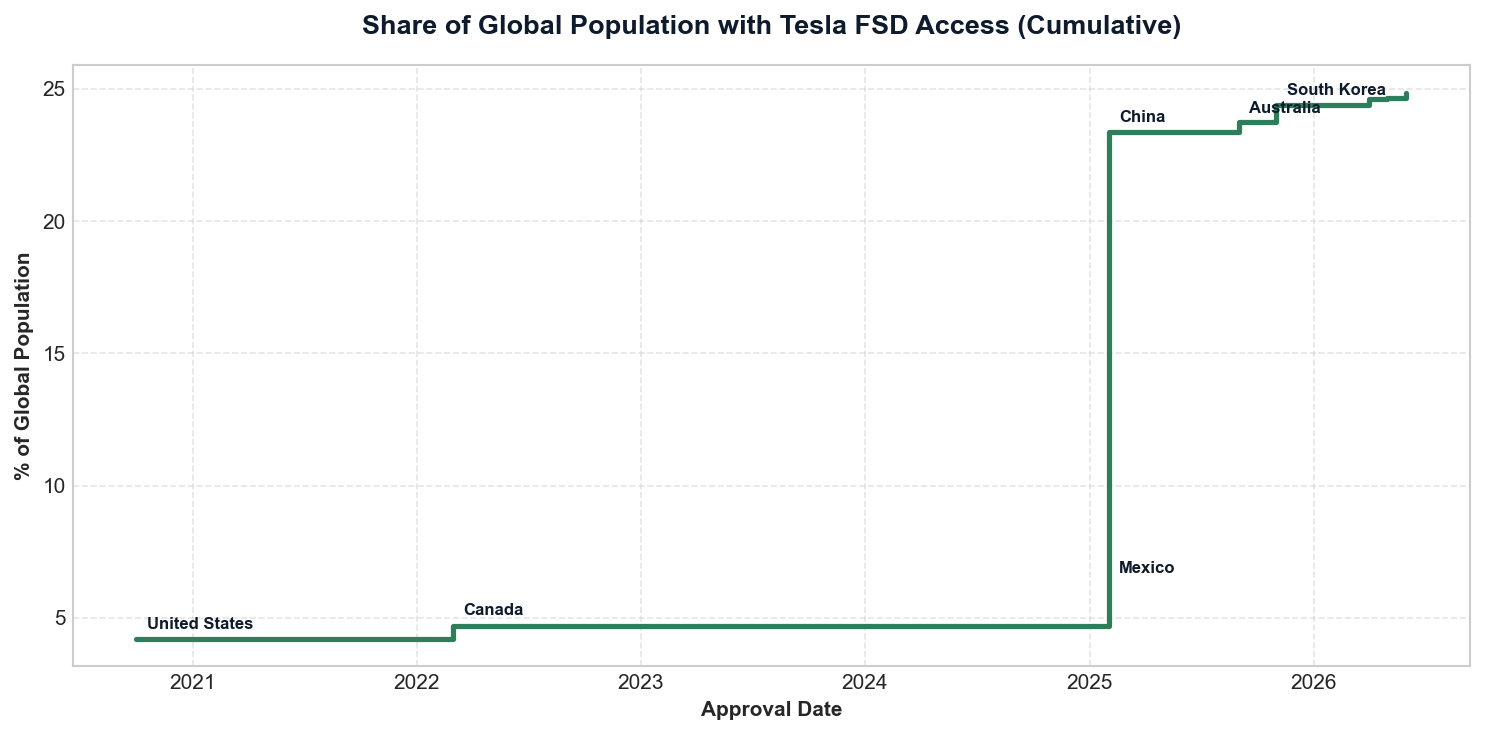

In [3]:
# Cumulative global access calculations
approvals_sorted = approvals.sort_values("approval_date").copy()
approvals_sorted["cumulative_pct"] = approvals_sorted["pct_global_population"].cumsum()
approvals_sorted.to_csv(OUT / "cumulative_access.csv", index=False)

# Plot cumulative global access share
fig, ax = plt.subplots(figsize=(10, 5))
ax.step(approvals_sorted["approval_date"], approvals_sorted["cumulative_pct"], where="post", color="#2E7D5B", lw=2.5)
ax.set_title("Share of Global Population with Tesla FSD Access (Cumulative)", fontsize=13, pad=15, fontweight='bold', color='#0E1B2C')
ax.set_ylabel("% of Global Population", fontsize=10, fontweight='bold')
ax.set_xlabel("Approval Date", fontsize=10, fontweight='bold')
ax.grid(True, linestyle="--", alpha=0.5)

# Annotate major approval countries
for _, r in approvals_sorted.iterrows():
    if r["pct_global_population"] > 0.3:
        ax.annotate(r["country"], (r["approval_date"], r["cumulative_pct"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8, fontweight='bold', color="#0E1B2C")

fig.tight_layout()
fig.savefig(IMG / "cumulative_access.png", dpi=150)
plt.show()

Headline Approved Population: 2,064,842,194
Usable (Live) Population:      638,822,401 (30.9% of approved)


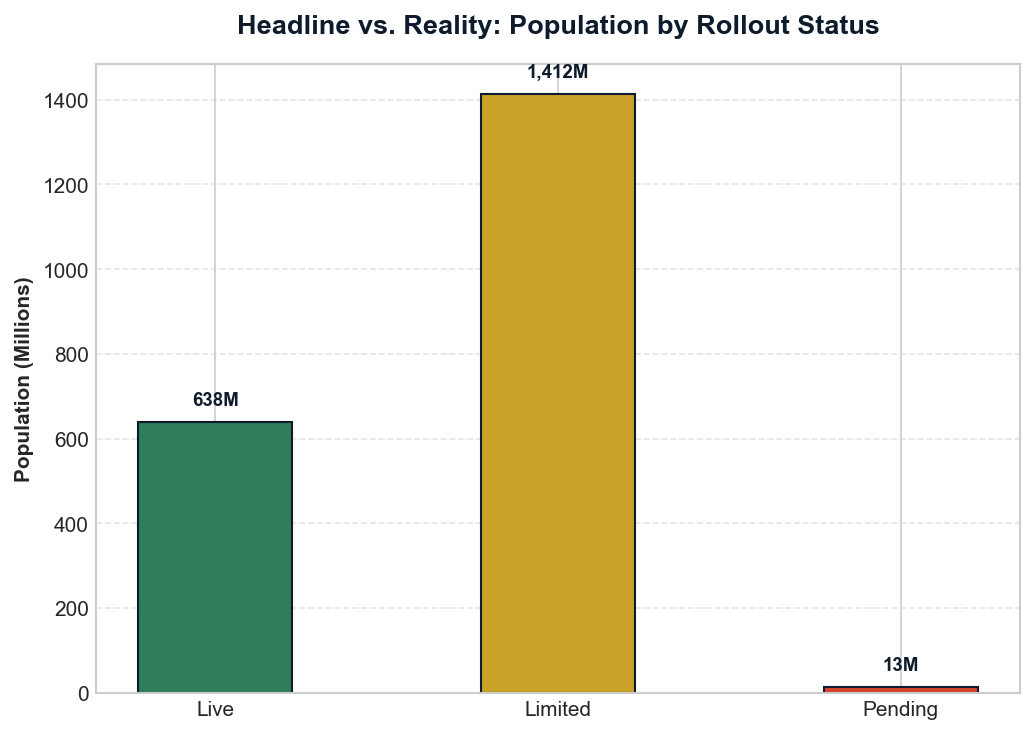

In [4]:
# Population summary by Status
live_pop = approvals.loc[approvals.status == "live", "population"].sum()
total_pop = approvals["population"].sum()
print(f"Headline Approved Population: {total_pop:,}")
print(f"Usable (Live) Population:      {live_pop:,} ({live_pop/total_pop:.1%} of approved)")

status_grouped = approvals.groupby("status")["population"].sum().reset_index()
status_grouped["status"] = pd.Categorical(status_grouped["status"], categories=["live", "limited", "pending"], ordered=True)
status_grouped = status_grouped.sort_values("status")

# Plot bar chart comparing headline vs reality
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#2E7D5B", "#C9A227", "#D6452B"]
bars = ax.bar(status_grouped["status"].str.capitalize(), status_grouped["population"] / 1e6, color=colors, edgecolor='#0E1B2C', width=0.45)
ax.set_title("Headline vs. Reality: Population by Rollout Status", fontsize=13, pad=15, fontweight='bold', color='#0E1B2C')
ax.set_ylabel("Population (Millions)", fontsize=10, fontweight='bold')
ax.grid(True, axis='y', linestyle="--", alpha=0.5)

# Labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 30, f"{int(height):,}M",
            ha='center', va='bottom', fontsize=9, fontweight='bold', color="#0E1B2C")

fig.tight_layout()
fig.savefig(IMG / "status_breakdown.png", dpi=150)
plt.show()

## 3. Regional FSD Access Distribution
To analyze the thesis **"Adoption is shaped more by regulation than by technology"**, we break down current approvals by geographic region (North America, Asia-Pacific, Europe) and rollout status. 

As shown, North America has an almost entirely Live rollout. Asia-Pacific has a massive approved population, but it is restricted by China's Limited status (due to data-compliance rules). Europe has approval, but a significant portion of its approved population is still Pending rollout.

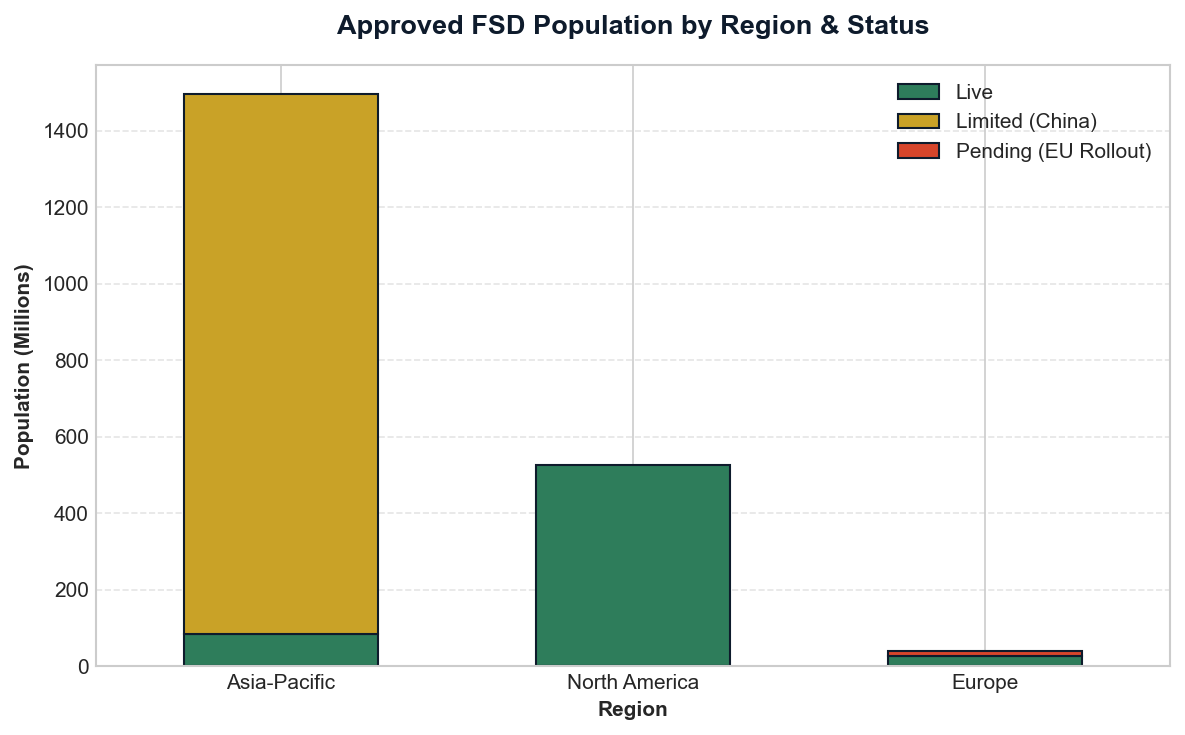

In [5]:
# Regional pivot of population by status
region_status = approvals.pivot_table(index="region", columns="status", values="population", aggfunc="sum", fill_value=0)
for col in ["live", "limited", "pending"]:
    if col not in region_status.columns:
        region_status[col] = 0
region_status = region_status[["live", "limited", "pending"]]
region_status = region_status.loc[region_status.sum(axis=1).sort_values(ascending=False).index]

# Regional breakdown stacked bar chart
fig, ax = plt.subplots(figsize=(8, 5))
(region_status / 1e6).plot(kind="bar", stacked=True, color=["#2E7D5B", "#C9A227", "#D6452B"], ax=ax, edgecolor='#0E1B2C', width=0.55)
ax.set_title("Approved FSD Population by Region & Status", fontsize=13, pad=15, fontweight='bold', color='#0E1B2C')
ax.set_ylabel("Population (Millions)", fontsize=10, fontweight='bold')
ax.set_xlabel("Region", fontsize=10, fontweight='bold')
ax.legend(["Live", "Limited (China)", "Pending (EU Rollout)"], loc="upper right")
ax.grid(True, axis='y', linestyle="--", alpha=0.5)
plt.xticks(rotation=0)

fig.tight_layout()
fig.savefig(IMG / "regional_distribution.png", dpi=150)
plt.show()

## 4. Expansion Pipeline & Untapped Opportunities
The biggest expansion opportunities lie in untapped markets. We rank the countries in the expansion pipeline by population to identify where Tesla's regulatory and localization resources will yield the highest return.

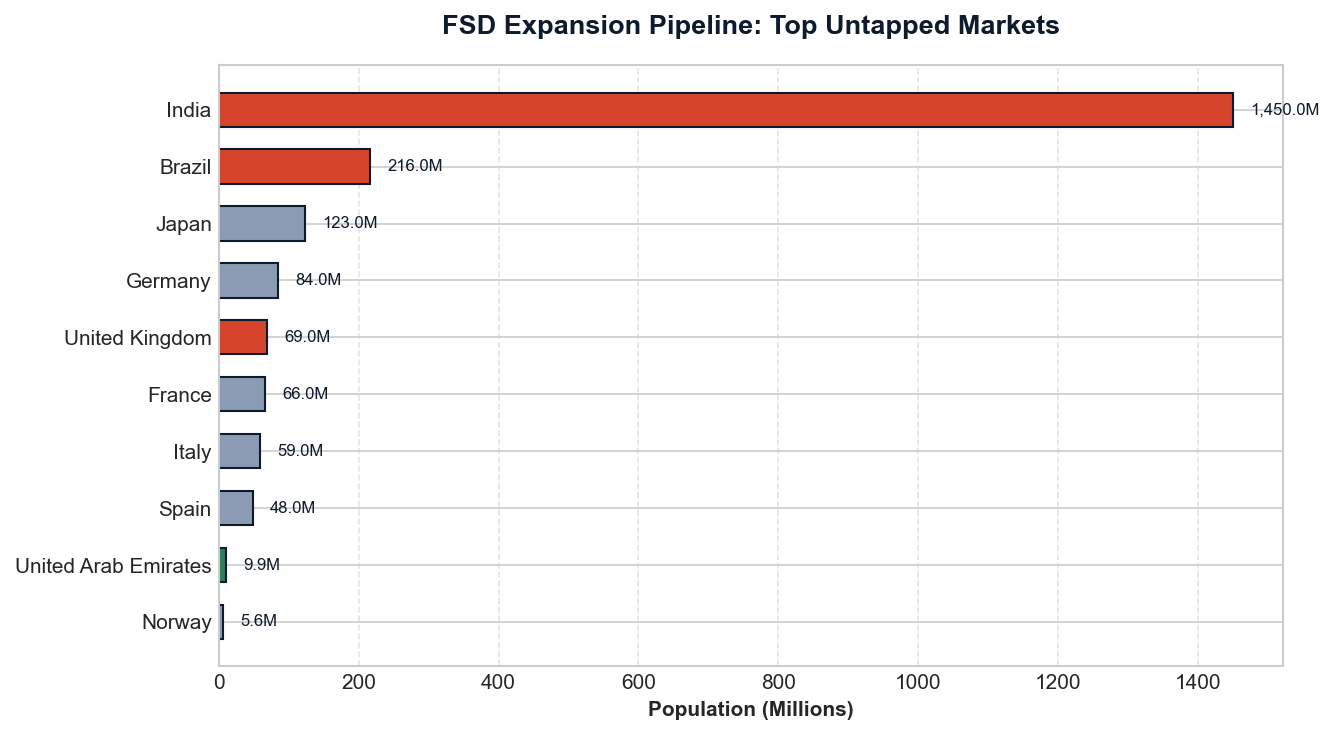

In [6]:
# Pipeline opportunities ranking
pipeline_ranked = pipeline.sort_values("population", ascending=False).copy()
pipeline_ranked.to_csv(OUT / "pipeline_ranked.csv", index=False)

# Plot pipeline opportunities horizontal bar chart
fig, ax = plt.subplots(figsize=(9, 5))
colors_pipe = ['#8b9bb4' if x in ['pipeline', 'pipeline_2026'] else '#2E7D5B' if x == 'road_testing' else '#d6452b' for x in pipeline_ranked['status_2026q2']]
bars_p = ax.barh(pipeline_ranked["country"], pipeline_ranked["population"] / 1e6, color=colors_pipe, edgecolor='#0E1B2C', height=0.6)
ax.set_title("FSD Expansion Pipeline: Top Untapped Markets", fontsize=13, pad=15, fontweight='bold', color='#0E1B2C')
ax.set_xlabel("Population (Millions)", fontsize=10, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, axis='x', linestyle="--", alpha=0.5)

# Labels
for bar in bars_p:
    width = bar.get_width()
    ax.text(width + 25, bar.get_y() + bar.get_height()/2., f"{width:,.1f}M",
            ha='left', va='center', fontsize=8, color="#0E1B2C")

fig.tight_layout()
fig.savefig(IMG / "pipeline_opportunity.png", dpi=150)
plt.show()

## 5. Regional Regulatory Readiness Score (0-5 Index)
To analyze regulatory barriers across regions, we build a **Regulatory Readiness Index** (0-5 scale) across: US, EU, and China. 

- **Legal Support**: Government policy backing (1=Low/Hostile, 5=High/Favorable).
- **Testing Permissions**: Ease of testing supervised or autonomous fleets (1=Hard, 5=Easy).
- **Data Compliance Ease**: Lower complexity of local privacy/security rules (1=Extremely Hard/GDPR, 5=Simple/Unified).
- **Overall Score**: Weighted score out of 5 representing overall readiness for FSD mass deployment.

,Region,Legal Support,Testing Permissions,Data Compliance Ease,Overall Score
0,United States,3.0,5.0,3.0,3.5
1,European Union,1.0,2.0,1.0,2.0
2,China,4.0,3.0,2.0,4.0


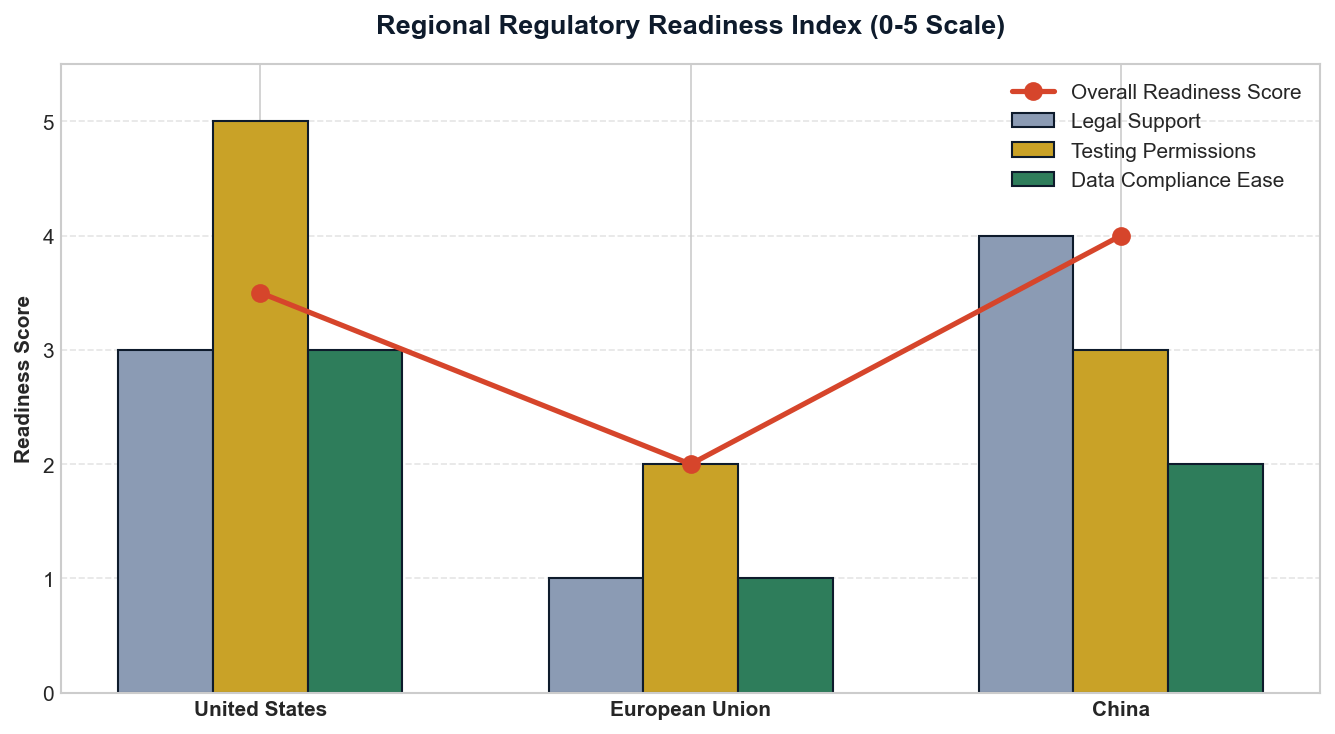

In [7]:
readiness_data = {
    "Region": ["United States", "European Union", "China"],
    "Legal Support": [3.0, 1.0, 4.0],
    "Testing Permissions": [5.0, 2.0, 3.0],
    "Data Compliance Ease": [3.0, 1.0, 2.0],
    "Overall Score": [3.5, 2.0, 4.0]
}

readiness_df = pd.DataFrame(readiness_data)
display(readiness_df)

# Grouped bar chart
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(readiness_df["Region"]))
width = 0.22

ax.bar(x - width, readiness_df["Legal Support"], width, label='Legal Support', color='#8b9bb4', edgecolor='#0E1B2C')
ax.bar(x, readiness_df["Testing Permissions"], width, label='Testing Permissions', color='#C9A227', edgecolor='#0E1B2C')
ax.bar(x + width, readiness_df["Data Compliance Ease"], width, label='Data Compliance Ease', color='#2E7D5B', edgecolor='#0E1B2C')
ax.plot(x, readiness_df["Overall Score"], color='#D6452B', marker='o', linewidth=2.5, label='Overall Readiness Score', markersize=8)

ax.set_title("Regional Regulatory Readiness Index (0-5 Scale)", fontsize=13, pad=15, fontweight='bold', color='#0E1B2C')
ax.set_xticks(x)
ax.set_xticklabels(readiness_df["Region"], fontsize=10, fontweight='bold')
ax.set_ylabel("Readiness Score", fontsize=10, fontweight='bold')
ax.set_ylim(0, 5.5)
ax.legend(loc="upper right")
ax.grid(True, axis='y', linestyle="--", alpha=0.5)

fig.tight_layout()
fig.savefig(IMG / "regulatory_readiness.png", dpi=150)
plt.show()

## 6. Safety Reality vs. Public Narrative
A key obstacle to global FSD adoption is public perception. Media reporting often focuses heavily on individual crashes, creating a public perception that supervised FSD is highly dangerous. 

However, Tesla's empirical safety records (measured as average **Miles Between Crashes**) show that FSD is roughly **10.5x safer than the US average driver** and **3.9x safer than driving a Tesla manually without ADAS**. 

Below, we contrast empirical safety performance (higher is better) with relative media scrutiny volume (higher is worse), demonstrating that **Public narratives don’t always match incident data**.

,Category,Miles Between Crashes (Millions),Relative Media Negative Scrutiny
0,US Avg (All Cars),0.67,5
1,Tesla (No ADAS),1.80,12
2,Tesla Autopilot,5.40,60
3,Tesla FSD Supervised,7.08,95


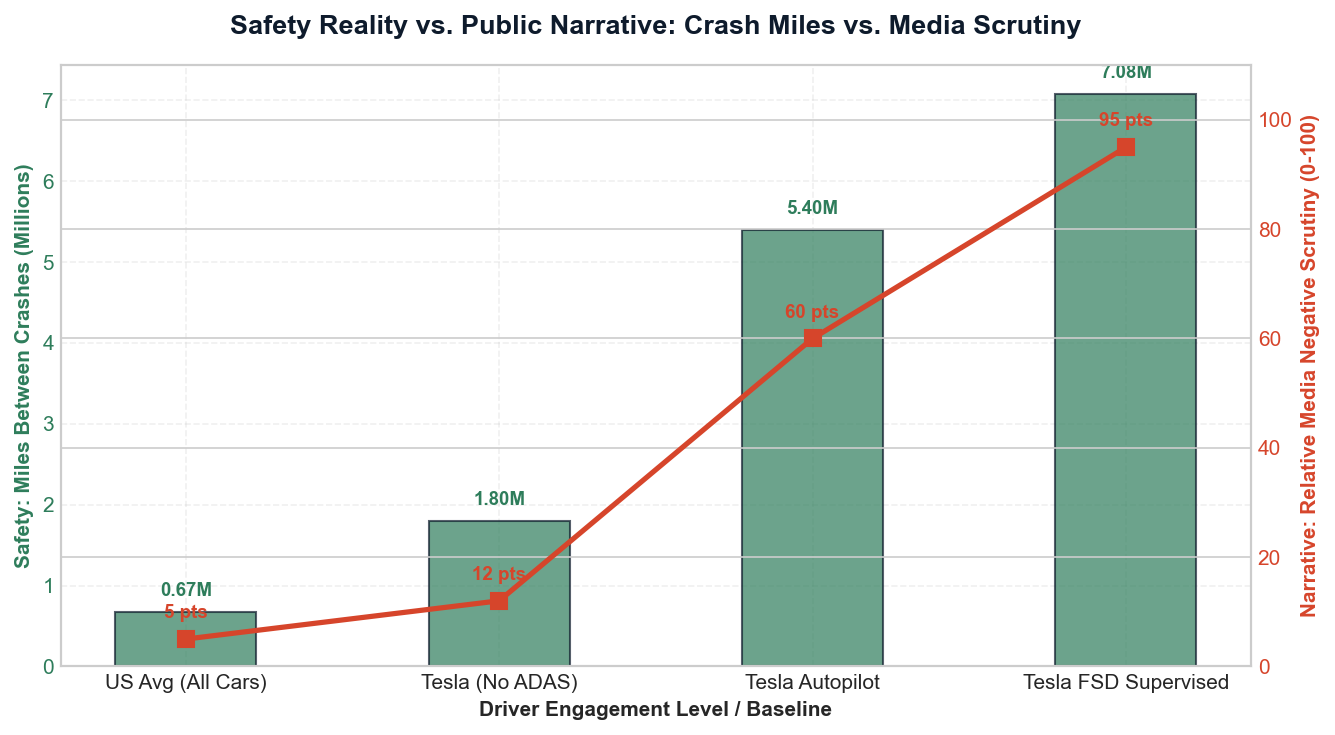

In [8]:
safety_metrics = {
    "Category": ["US Avg (All Cars)", "Tesla (No ADAS)", "Tesla Autopilot", "Tesla FSD Supervised"],
    "Miles Between Crashes (Millions)": [0.67, 1.80, 5.40, 7.08],
    "Relative Media Negative Scrutiny": [5, 12, 60, 95]
}
safety_df = pd.DataFrame(safety_metrics)
display(safety_df)

fig, ax1 = plt.subplots(figsize=(9, 5))

# Primary Y-axis: Miles between crashes (Bars)
color_bar = '#2E7D5B'
ax1.set_xlabel('Driver Engagement Level / Baseline', fontsize=10, fontweight='bold')
ax1.set_ylabel('Safety: Miles Between Crashes (Millions)', color=color_bar, fontsize=10, fontweight='bold')
bars = ax1.bar(safety_df["Category"], safety_df["Miles Between Crashes (Millions)"], color=color_bar, alpha=0.7, edgecolor='#0E1B2C', width=0.45)
ax1.tick_params(axis='y', labelcolor=color_bar)
ax1.grid(True, linestyle="--", alpha=0.3)

# Annotate bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.15, f"{height:.2f}M",
             ha='center', va='bottom', color=color_bar, fontweight='bold', fontsize=9)

# Secondary Y-axis: Media Scrutiny (Line)
ax2 = ax1.twinx()
color_line = '#D6452B'
ax2.set_ylabel('Narrative: Relative Media Negative Scrutiny (0-100)', color=color_line, fontsize=10, fontweight='bold')
ax2.plot(safety_df["Category"], safety_df["Relative Media Negative Scrutiny"], color=color_line, marker='s', linewidth=2.5, markersize=8, label="Media Negative Scrutiny")
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.set_ylim(0, 110)

# Annotate line points
for i, txt in enumerate(safety_df["Relative Media Negative Scrutiny"]):
    ax2.annotate(f"{txt} pts", (safety_df["Category"].iloc[i], safety_df["Relative Media Negative Scrutiny"].iloc[i]),
                 textcoords="offset points", xytext=(0, 10), ha='center', color=color_line, fontweight='bold', fontsize=9)

ax1.set_title("Safety Reality vs. Public Narrative: Crash Miles vs. Media Scrutiny", fontsize=13, pad=15, fontweight='bold', color='#0E1B2C')
fig.tight_layout()
fig.savefig(IMG / "safety_vs_narrative.png", dpi=150)
plt.show()

## 7. Software Releases and FSD Subscriptions
Another critical velocity metric is **Adoption Velocity** triggered by software advancements. 

We model the FSD Subscription Growth Index over time. It highlights how major software updates (such as v12.3 introducing the end-to-end neural network, along with a price reduction to $99/mo and a 1-month free trial) and regional regulatory breakthroughs trigger massive subscription spikes. This supports the thesis that **Major FSD releases create measurable subscription spikes**.

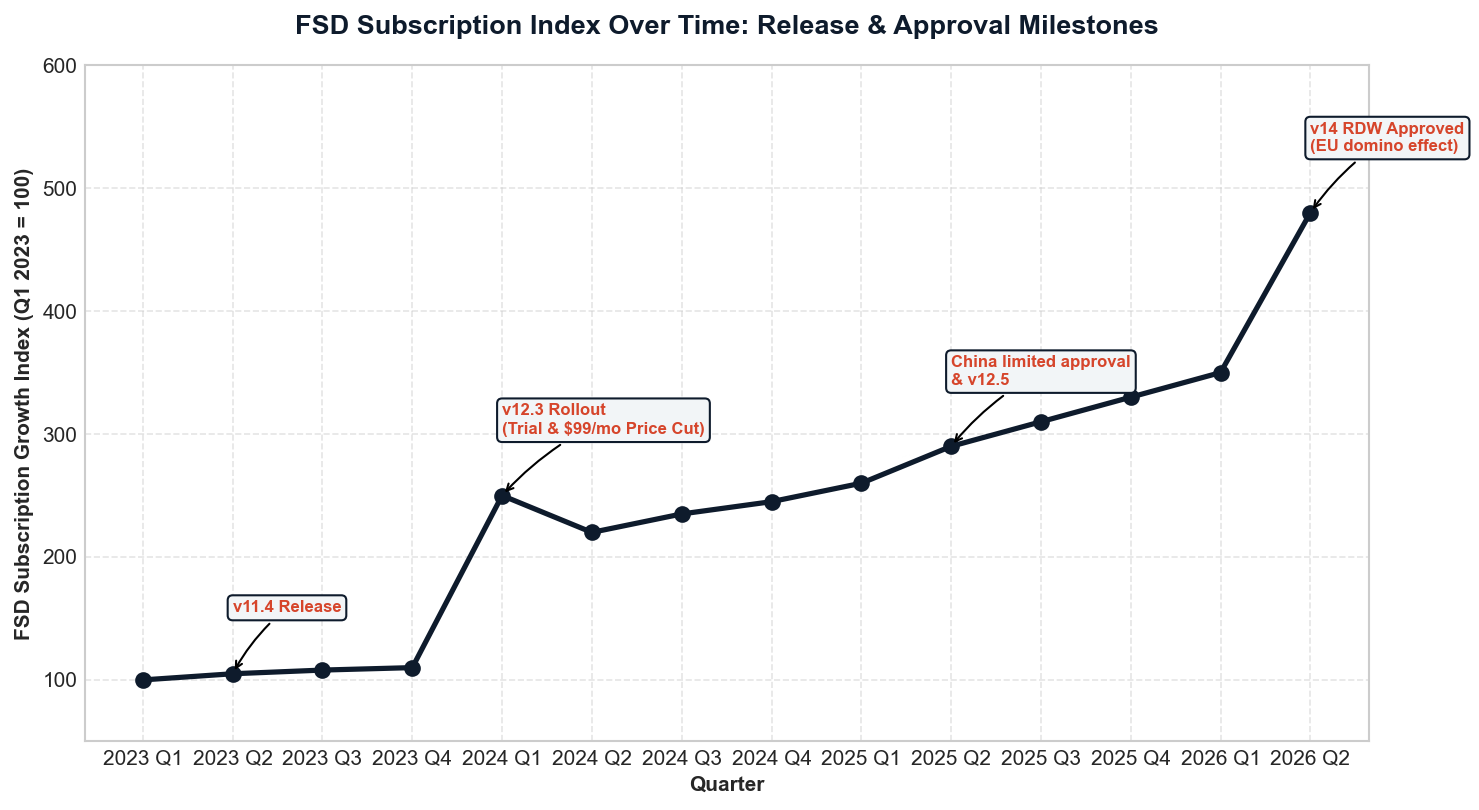

In [9]:
quarters = [
    "2023 Q1", "2023 Q2", "2023 Q3", "2023 Q4",
    "2024 Q1", "2024 Q2", "2024 Q3", "2024 Q4",
    "2025 Q1", "2025 Q2", "2025 Q3", "2025 Q4",
    "2026 Q1", "2026 Q2"
]
sub_index = [100, 105, 108, 110, 250, 220, 235, 245, 260, 290, 310, 330, 350, 480]
release_events = {
    "2023 Q2": "v11.4 Release",
    "2024 Q1": "v12.3 Rollout\n(Trial & $99/mo Price Cut)",
    "2025 Q2": "China limited approval\n& v12.5",
    "2026 Q2": "v14 RDW Approved\n(EU domino effect)"
}

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(quarters, sub_index, marker='o', color='#0E1B2C', linewidth=2.5, markersize=7)
ax.set_title("FSD Subscription Index Over Time: Release & Approval Milestones", fontsize=13, pad=15, fontweight='bold', color='#0E1B2C')
ax.set_ylabel("FSD Subscription Growth Index (Q1 2023 = 100)", fontsize=10, fontweight='bold')
ax.set_xlabel("Quarter", fontsize=10, fontweight='bold')
ax.grid(True, linestyle="--", alpha=0.5)

# Annotations
for q, event in release_events.items():
    idx = quarters.index(q)
    val = sub_index[idx]
    ax.annotate(event, xy=(q, val), xytext=(q, val + 50),
                arrowprops=dict(facecolor='#D6452B', arrowstyle="->", connectionstyle="arc3,rad=.1"),
                fontsize=8, fontweight='bold', color='#D6452B',
                bbox=dict(boxstyle="round,pad=0.3", fc="#F2F5F7", ec="#0E1B2C", lw=1))

ax.set_ylim(50, 600)
fig.tight_layout()
fig.savefig(IMG / "subscription_spikes.png", dpi=150)
plt.show()

## 8. US Regulatory Scope Growth (NHTSA Investigations)
Lastly, we examine the velocity of regulatory pressure. In the US, the growth of vehicles under NHTSA FSD investigations has been steep. 

As probes expanded from 2.4M vehicles in 2024 to a 3.2M-vehicle Engineering Analysis in 2026, regulatory compliance and proactive system alerts (such as for camera occlusion/glare) represent the critical path for Tesla to maintain FSD availability in its home market.

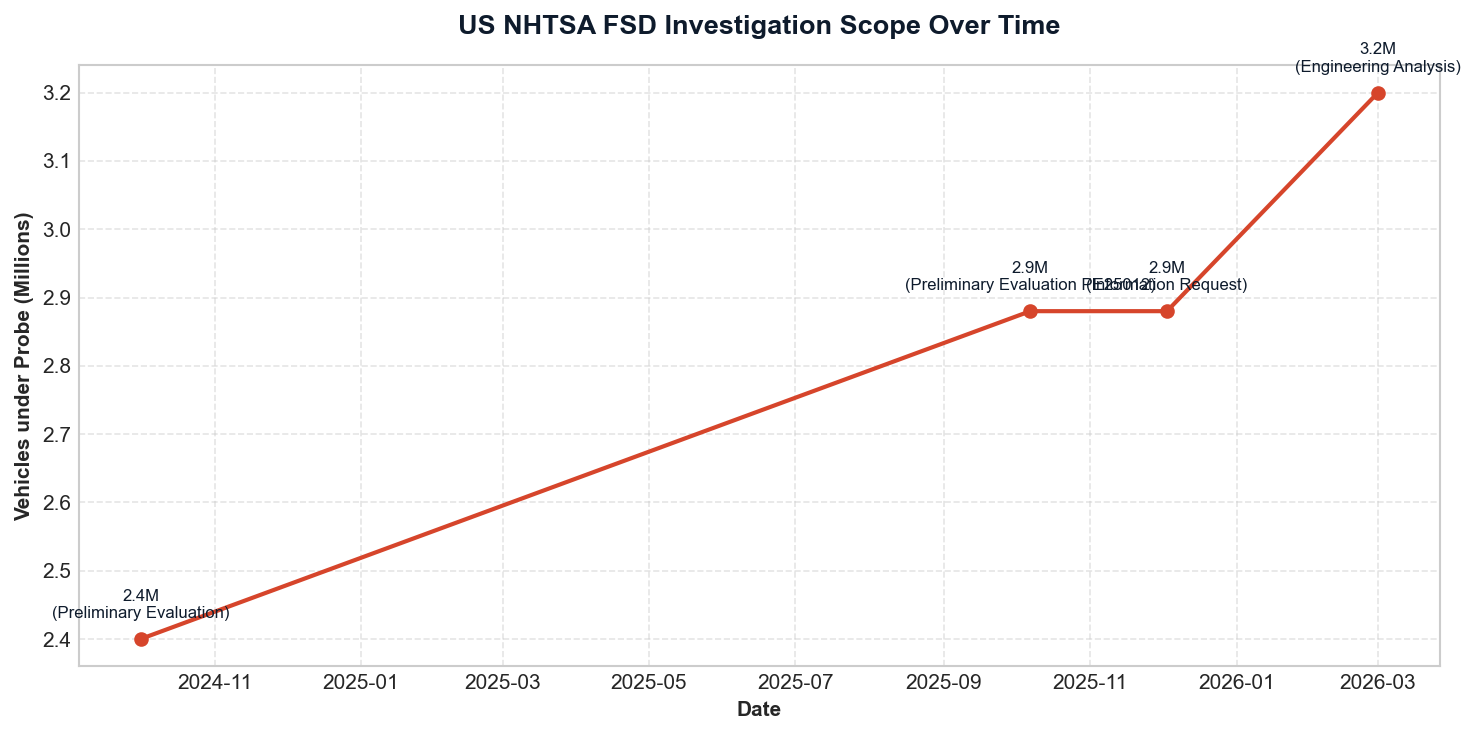

Analysis notebook execution finished successfully. All charts exported to docs/img/


In [10]:
# Filter out rows without vehicle scope
scope = events.dropna(subset=["vehicles_in_scope"]).copy()
scope["vehicles_in_scope"] = pd.to_numeric(scope["vehicles_in_scope"], errors="coerce")
scope = scope.dropna(subset=["vehicles_in_scope"])

# Plot NHTSA investigation scope
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(scope["event_date"], scope["vehicles_in_scope"] / 1e6, marker="o", color="#D6452B", lw=2, markersize=6)
ax.set_title("US NHTSA FSD Investigation Scope Over Time", fontsize=13, pad=15, fontweight='bold', color='#0E1B2C')
ax.set_ylabel("Vehicles under Probe (Millions)", fontsize=10, fontweight='bold')
ax.set_xlabel("Date", fontsize=10, fontweight='bold')
ax.grid(True, linestyle="--", alpha=0.5)

# Annotations
for _, r in scope.iterrows():
    ax.annotate(f"{r['vehicles_in_scope']/1e6:.1f}M\n({r['event_type']})", (r["event_date"], r["vehicles_in_scope"]/1e6),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8, color="#0E1B2C")

fig.tight_layout()
fig.savefig(IMG / "nhtsa_scope.png", dpi=150)
plt.show()

con.close()
print("Analysis notebook execution finished successfully. All charts exported to docs/img/")